# Tutorial 7 - Pandas, Numpy & Team Collaboration
### FINM3422 - Data Cleaning, Alignment, Multi‑Dataset Operations
---
This tutorial helps you build **real confidence** with Python, pandas, and numpy.
It is **not related to any assessment** - it builds generic modelling skills used in finance and data analysis.

You will:
- Clean small finance‑flavoured datasets
- Align dates & practice time‑series operations
- Merge DataFrames correctly
- Understand vectorisation vs loops
- Produce diagnostic charts
- Practice GitHub collaboration (branches + PRs) as a **team**

---

## 1. Environment Info

In [24]:
import sys, pandas as pd, numpy as np
print('Python:', sys.version)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)

Python: 3.13.13 (tags/v3.13.13:01104ce, Apr  7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]
pandas: 3.0.2
numpy: 2.4.4


## 2. Imports & Settings

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme()

from IPython import embed

## 3. Generate Synthetic Finance‑Flavoured Datasets (No CSVs Needed)
We will create three small datasets directly in this notebook.
Each series mimics simple monthly price or return behaviour.

### ✅ Dataset A — Monthly prices for Asset A
### ✅ Dataset B — Monthly prices for Asset B
### ✅ Dataset C — Monthly returns for Asset C

Later, you will clean, align, merge, and analyse them.

In [26]:
# Generate synthetic data
dates = pd.date_range(start='2021-01-01', periods=24, freq='ME')

np.random.seed(0)
assetA = 100 * (1 + 0.01*np.random.randn(24)).cumprod() # Prices
assetB = 80 * (1 + 0.015*np.random.randn(24)).cumprod() # Prices
assetC_returns = np.random.normal(loc=0.01, scale=0.03, size=24)  # Already in returns

dfA = pd.DataFrame({'PriceA': assetA}, index=dates)
dfB = pd.DataFrame({'PriceB': assetB}, index=dates)
dfC = pd.DataFrame({'RetC': assetC_returns}, index=dates)

dfA.head()
dfB.head()
dfC.head()

,RetC
2021-01-31,-0.0384
2021-02-28,0.0036
2021-03-31,-0.0169
2021-04-30,0.0216
2021-05-31,-0.0053


## 4. Inspection Tasks — *Team Split*
Assign ONE task per teammate. Add conclusions in markdown.

### ✅ Tasks:
- Inspect `.info()` on one dataset
- Inspect `.describe()`
- Check for missing values using `.isna().sum()`
- Check index type
- Infer frequency using `pd.infer_freq()`
- Check for duplicated dates using `.duplicated()`

In [27]:
# Example cell — students create their own below
dfA.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 24 entries, 2021-01-31 to 2022-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PriceA  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes


In [28]:
# ASSET A

# Inspect the data using info and describe functions.
dfA.info()
dfA.describe()

# Check for missing values.
dfA.isna().sum

dfA.index.dtype

dfA.index.inferred_type
isinstance(dfA.index, pd.DatetimeIndex)

dfA.index.inferred_freq
pd.infer_freq(dfA.index)

# Check for duplicated dates.
dfA.duplicated()

# Complete the same thing for B and C.

<class 'pandas.DataFrame'>
DatetimeIndex: 24 entries, 2021-01-31 to 2022-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PriceA  24 non-null     float64
dtypes: float64(1)
memory usage: 384.0 bytes


2021-01-31    False
2021-02-28    False
2021-03-31    False
2021-04-30    False
2021-05-31    False
2021-06-30    False
2021-07-31    False
2021-08-31    False
2021-09-30    False
2021-10-31    False
2021-11-30    False
2021-12-31    False
2022-01-31    False
2022-02-28    False
2022-03-31    False
2022-04-30    False
2022-05-31    False
2022-06-30    False
2022-07-31    False
2022-08-31    False
2022-09-30    False
2022-10-31    False
2022-11-30    False
2022-12-31    False
Freq: ME, dtype: bool

## 5. Cleaning Tasks — *Team Split*
### Why we clean data
Real datasets contain issues: inconsistent dates, missing observations, incorrect datatypes.
Finance models fail if the underlying data is misaligned or dirty.

### ✅ Tasks (each member gets one):
- Convert index to true month‑end using `.to_period('M').to_timestamp('M')`
- Sort index and verify ascending order
- Forward fill missing prices (if any)
- Convert prices → returns using `.pct_change().dropna()`
- Convert string columns → numeric (if needed)
- Rename columns to standardised names (e.g., `PriceA`, `PriceB`, `RetC`)
- Add markdown describing what issue you fixed and why

In [ ]:
# Example transformation (students extend)
dfA.index = dfA.index.to_period('M').to_timestamp('M')
dfA = dfA.sort_index()
dfA.head()

# Convert index to month-end.
dfA.to_period('M').to_timestamp('M')
dfB.to_period('M').to_timestamp('M')
dfC.to_period('M').to_timestamp('M')

# Sort
dfA = dfA.sort_index()
dfB = dfB.sort_index()
dfC = dfC.sort_index()

## 6. Time-Series Transformations 
### ✅ Compute simple monthly returns
### ✅ Wealth index
### ✅ Rolling averages/volatility
### ✅ Correlations between assets

These operations are used everywhere in finance, investment operations, and risk analysis.

In [36]:
# Returns for A and B
returnsA = dfA.pct_change().dropna()
returnsB = dfB.pct_change().dropna()

# Wealth index
wealthA = (1 + returnsA['PriceA']).cumprod()
wealthA.head()
rolling_meanA = returnsA['PriceA'].rolling(3).mean()
rolling_volA = returnsA['PriceA'].rolling(3).std()

rolling_meanB = returnsB['PriceB'].rolling(3).mean()
rolling_volB = returnsB['PriceB'].rolling(3).std()

corrAB = returnsA['PriceA'].corr(returnsB['PriceB'])


## 7. Merging / Joining Multiple DataFrames
Merging/joining datasets is crucial when combining sleeves, markets, or indicators.

### ✅ Try these joins:
- `inner` join
- `outer` join (shows missing dates if any)
- `left` join

Explain in markdown what difference you observed.

In [40]:
combined_inner = dfA.join(dfB, how='inner')
combined_inner.head()

,PriceA,PriceB
2021-01-31,101.7641,82.7237
2021-02-28,102.1713,80.9190
2021-03-31,103.1713,80.9746
2021-04-30,105.4832,80.7472
2021-05-31,107.4532,82.6037


In [38]:
combined_outer = dfA.join(dfB, how = 'outer')
combined_outer.head()

,PriceA,PriceB
2021-01-31,101.7641,82.7237
2021-02-28,102.1713,80.9190
2021-03-31,103.1713,80.9746
2021-04-30,105.4832,80.7472
2021-05-31,107.4532,82.6037


In [39]:
combined_left = dfA.join(dfB, how = 'left')
combined_left.head()

,PriceA,PriceB
2021-01-31,101.7641,82.7237
2021-02-28,102.1713,80.9190
2021-03-31,103.1713,80.9746
2021-04-30,105.4832,80.7472
2021-05-31,107.4532,82.6037


## 8. Vectorisation vs Loops
Vectorised operations in pandas/numpy are *much faster* than Python loops.
This matters in finance where datasets can be millions of rows.

### ✅ Compare performance, clarity, correctness.

In [ ]:
# Loop version (slow)
import time
start = time.time()
out = []
for r in returnsA['PriceA']:
    out.append(r * 12)  # e.g., annualising monthly return (not exact)
loop_res = pd.Series(out, index=returnsA.index)
end = time.time()
print(f"Loop elapsed time: {end - start:.6f} seconds")

UsageError: Line magic function `%%timeit` not found.


In [50]:

import time
start = time.time()
# Your loop code here.
out = []
for r in returnsA['PriceA']:
    out.append (r * 12)
loop_res = pd.Series (out, index=returnsA.index)
end = time.time()
print(f"Elapsed time: {end - start:.6f} seconds")


Elapsed time: 0.000328 seconds


In [ ]:
# Vectorised version (fast)
import time
start = time.time()
vec_res = returnsA['PriceA'] * 12
end = time.time()
print(f"Vectorized elapsed time: {end - start:.6f} seconds")

UsageError: Line magic function `%%timeit` not found.


## 9. Diagnostic Charts
Producing visual checks helps reveal missing data, misalignment, noise, or unusual movements.
Each team member creates **one chart**.

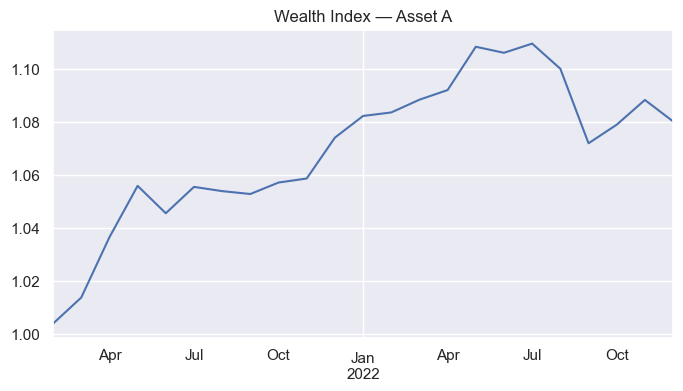

In [52]:
wealthA.plot(title='Wealth Index — Asset A', figsize=(8,4))
plt.show()

## 10. Team GitHub Workflow — Feature Branches & PRs

Each student:
1. Create a branch: `feature/t7_name_task`
2. Complete their assigned notebook task
3. Stage → Commit → Push (GUI only)
4. Open a Pull Request in the tutorial-team repo
5. Request review

Team lead:
- Reviews PRs
- Merges when safe
- Runs ‘Run All’ to check final notebook
- Pushes clean version


## 11. Final Checks Before Leaving

✅ Notebook runs top-to-bottom (Run All)
✅ No merge conflicts
✅ Data is clean
✅ Charts work
✅ All team PRs merged into `main`

---
**End of Tutorial 7 — Great work!**